# 04b - Step 4 controls: window length and precipitation zero provenance

**Purpose:** two controls, run before adding more detectors, on confounds
that would otherwise be baked into Step 7's central analysis.

An interim look at the four detectors already on disk (Steps 3-4) found
their flagged sets overlap far less than the study design assumed —
pairwise Jaccard of roughly 0.06-0.23 at matched alarm budgets, and near
zero on `pressure` and `luminous_intensity` specifically. Before that is
interpreted as evidence about *method families*, two alternative
explanations have to be ruled out or measured:

1. **Time scale, not family.** Step 3 scores over 6-hour rolling windows;
   Step 4 builds 1-hour feature windows. A disagreement between those two
   corners currently mixes "different family" with "different time scale",
   and the paper's claim is about the former. This control re-runs Step 4's
   two methods on 6-hour feature windows, changing *only* the window
   length, so the two effects can be separated.
2. **Synthetic zeros, not agreement.** Almost all of the cross-method
   agreement that does exist sits in `precipitation`, the one channel whose
   missing bins are zero-filled at export. If that agreement rests on
   fabricated dry bins, it is an artifact of data provenance rather than
   methodological convergence.

Neither control adds a method to the five-method study. The window-length
variants are written to their own file with their own method names and are
explicitly **not** part of the Step 7 method roster.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from uema.agree import (
    align_scores,
    jaccard_by_sensor,
    jaccard_matrix,
    matched_budget_flags,
    native_flags,
)
from uema.density import (
    IFOREST_THRESHOLD,
    LOF_THRESHOLD,
    isolation_forest_scores,
    lof_scores,
    window_features,
)
from uema.detect import SCHEMA_COLUMNS, build_detection_table
from uema.silver import consolidate_stations, fill_gaps, suspect_zero_precipitation
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()
pd.set_option("display.width", 220)

REPORT_DIR = Path("..") / "reports" / "data_audit"
DETECT_DIR = Path("..") / "reports" / "detections"

SENSORS = ("pressure", "precipitation", "luminous_intensity")
CONTROL_WINDOW_BINS = 36  # 6h, matching Step 3's scoring window
BUDGET = 0.01

## Data prep

Same 12 in-scope stations and same preparation as Steps 1-4. Both the
gap-filled frame (what every detector runs on) and the unfilled frame are
kept: the provenance control needs the unfilled one, because once
`fill_gaps` bridges a short pressure/luminous-intensity outage, the
missing-sibling signature it depends on is gone.

In [2]:
recommendation = pd.read_csv(REPORT_DIR / "station_recommendation.csv", index_col="station")
raw_frames = consolidate_stations(recommendation)

unfilled = {station: df.resample("10min").mean() for station, df in raw_frames.items()}
station_frames = {station: fill_gaps(df, max_gap="6h") for station, df in unfilled.items()}
len(station_frames)

12

## Control 1 - window length

`uema.density.window_features` already takes the window length as a
parameter, so this control changes exactly one thing: 6 bins (1h) becomes
36 bins (6h), matching Step 3's scoring window. Everything else — the four
features, the robust scaling, `n_neighbors`, the forest parameters, the
random seed, the published thresholds — is identical to Step 4.

If the Step 3 / Step 4 disagreement is largely a time-scale effect, these
6-hour variants should agree with Step 3's Z-score family noticeably more
than the 1-hour versions do. If agreement barely moves, the disagreement
is attributable to the method family, which is what the study's central
claim requires.

In [3]:
control_tables = []
for station, df10 in station_frames.items():
    for sensor in SENSORS:
        features = window_features(df10[sensor], window=CONTROL_WINDOW_BINS)

        lof = lof_scores(features)
        control_tables.append(
            build_detection_table(lof, station, sensor, "lof_6h", LOF_THRESHOLD)
        )

        iforest = isolation_forest_scores(features)
        control_tables.append(
            build_detection_table(
                iforest, station, sensor, "isolation_forest_6h", IFOREST_THRESHOLD
            )
        )

control = pd.concat(control_tables, ignore_index=True)
assert list(control.columns) == SCHEMA_COLUMNS
control.to_parquet(DETECT_DIR / "step4b_window_control.parquet", index=False)
control.groupby(["method"]).agg(n_scored=("flagged", "size"), flagged_rate=("flagged", "mean"))

/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


/home/isaac/Documents/uema/.venv/lib/python3.14/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,n_scored,flagged_rate
method,,
isolation_forest_6h,1911399,0.210914
lof_6h,1911399,0.018167


### Agreement with and without the time-scale change

All six methods are aligned on the rows every one of them scored
(`uema.agree.align_scores`, listwise) and compared two ways: at each
method's own published threshold, and at a matched 1% alarm budget per
station x sensor. Both views are reported because they answer different
questions — what each method actually decides, versus whether the methods
are looking at the same phenomena at all.

In [4]:
step3 = pd.read_parquet(DETECT_DIR / "step3_zscore_family.parquet")
step3 = step3[step3["method"] != "z_score_context_hour"]  # lux-only; not comparable across sensors
step4 = pd.read_parquet(DETECT_DIR / "step4_density_isolation.parquet")

detections = pd.concat([step3, step4, control], ignore_index=True)
wide = align_scores(detections)
print(f"rows scored by all {wide.shape[1]} methods: {len(wide):,}")

native = native_flags(detections, index=wide.index)
matched = matched_budget_flags(wide, budget=BUDGET)

print("\nnative flagged rate (%):")
print((native.mean() * 100).round(2).to_string())

rows scored by all 6 methods: 1,911,399



native flagged rate (%):
method
isolation_forest       16.68
isolation_forest_6h    21.09
lof                     1.31
lof_6h                  1.82
modified_z_score        2.57
z_score                 0.21


In [5]:
jac_native = jaccard_matrix(native)
jac_matched = jaccard_matrix(matched)

jac_native.to_csv(DETECT_DIR / "step4b_jaccard_native.csv")
jac_matched.to_csv(DETECT_DIR / "step4b_jaccard_matched.csv")

print("Jaccard at NATIVE thresholds")
print(jac_native.round(3).to_string())
print("\nJaccard at MATCHED 1% budget")
print(jac_matched.round(3).to_string())

Jaccard at NATIVE thresholds
                     isolation_forest  isolation_forest_6h    lof  lof_6h  modified_z_score  z_score
isolation_forest                1.000                0.550  0.024   0.035             0.092    0.013
isolation_forest_6h             0.550                1.000  0.020   0.041             0.072    0.009
lof                             0.024                0.020  1.000   0.048             0.031    0.006
lof_6h                          0.035                0.041  0.048   1.000             0.072    0.036
modified_z_score                0.092                0.072  0.031   0.072             1.000    0.078
z_score                         0.013                0.009  0.006   0.036             0.078    1.000

Jaccard at MATCHED 1% budget
                     isolation_forest  isolation_forest_6h    lof  lof_6h  modified_z_score  z_score
isolation_forest                1.000                0.242  0.096   0.038             0.136    0.096
isolation_forest_6h             

The control comparison itself: for each density method and each Step 3
statistical method, does moving the density method from a 1-hour to a
6-hour window move it closer to the statistical method?

In [6]:
pairs = []
for density in ("lof", "isolation_forest"):
    for statistical in ("z_score", "modified_z_score"):
        pairs.append(
            {
                "density_method": density,
                "statistical_method": statistical,
                "jaccard_1h": jac_matched.loc[density, statistical],
                "jaccard_6h": jac_matched.loc[f"{density}_6h", statistical],
            }
        )

window_effect = pd.DataFrame(pairs)
window_effect["change"] = window_effect["jaccard_6h"] - window_effect["jaccard_1h"]
window_effect["self_agreement_1h_vs_6h"] = [
    jac_matched.loc[row.density_method, f"{row.density_method}_6h"]
    for row in window_effect.itertuples()
]
window_effect.to_csv(DETECT_DIR / "step4b_window_effect.csv", index=False)
window_effect.round(4)

,density_method,statistical_method,jaccard_1h,jaccard_6h,change,self_agreement_1h_vs_6h
0,lof,z_score,0.0652,0.0376,-0.0277,0.0529
1,lof,modified_z_score,0.0701,0.0361,-0.0341,0.0529
2,isolation_forest,z_score,0.0958,0.0433,-0.0525,0.2419
3,isolation_forest,modified_z_score,0.1362,0.0680,-0.0682,0.2419


`self_agreement_1h_vs_6h` is the sanity anchor: how much a density
method agrees with *itself* under only a window-length change. If that is
also low, window length is a first-order driver of what these methods
flag, and any cross-family comparison at mismatched time scales is
confounded regardless of what the cross-method numbers say.

In [7]:
per_sensor = jaccard_by_sensor(matched)
per_sensor.to_csv(DETECT_DIR / "step4b_jaccard_matched_by_sensor.csv", index=False)
per_sensor.pivot_table(
    index=["method_a", "method_b"], columns="sensor", values="jaccard"
).round(3)

sensor                                   luminous_intensity  precipitation  pressure
method_a            method_b                                                        
isolation_forest    isolation_forest_6h               0.084          0.290     0.379
                    lof                               0.013          0.244     0.030
                    lof_6h                            0.008          0.051     0.055
                    modified_z_score                  0.045          0.368     0.020
                    z_score                           0.051          0.206     0.025
isolation_forest_6h lof                               0.006          0.151     0.021
                    lof_6h                            0.010          0.067     0.043
                    modified_z_score                  0.019          0.171     0.012
                    z_score                           0.007          0.096     0.019
lof                 lof_6h                            0.052          0.063     0.042
                    modified_z_score                  0.005          0.170     0.033
                    z_score                           0.006          0.126     0.058
lof_6h              modified_z_score                  0.007          0.057     0.041
                    z_score                           0.002          0.054     0.055
modified_z_score    z_score                           0.081          0.416     0.206

## Control 2 - precipitation zero provenance

`uema.silver.suspect_zero_precipitation` marks precipitation bins that are
exactly `0.0` at a time when *both* other sensors are missing — i.e. when
the station was most likely not reporting at all, so the zero is the
export-time fill rather than an observed dry ten minutes.

The check that this identifies a fill artifact rather than genuinely dry
weather is the nonzero count in the table below: if these were ordinary
dry-weather bins, some of them should occasionally contain rain.

In [8]:
provenance_rows = []
for station, df in unfilled.items():
    suspect = suspect_zero_precipitation(df)
    zeros = df["precipitation"].eq(0.0)
    offline = df["pressure"].isna() & df["luminous_intensity"].isna()
    provenance_rows.append(
        {
            "station": station,
            "n_bins": len(df),
            "zero_share": zeros.mean(),
            "suspect_zeros": int(suspect.sum()),
            "suspect_share_of_zeros": suspect.sum() / max(zeros.sum(), 1),
            "nonzero_while_offline": int((df["precipitation"].gt(0) & offline).sum()),
        }
    )

provenance = pd.DataFrame(provenance_rows).sort_values("suspect_share_of_zeros", ascending=False)
provenance.to_csv(DETECT_DIR / "step4b_precip_provenance.csv", index=False)
provenance.round(4)

,station,n_bins,zero_share,suspect_zeros,suspect_share_of_zeros,nonzero_while_offline
8,sede-central_losic-norte-2,25099,0.8170,9133,0.4454,0
6,sede-central_finca-3,88032,0.8823,30357,0.3909,0
1,recinto-santa-cruz,88027,0.9896,30462,0.3497,0
5,sede-central_finca-2,64410,0.9771,20768,0.3300,0
10,sede-guanacaste_liberia,88032,0.9417,23892,0.2882,0
3,sede-caribe_limon,38802,0.9432,8730,0.2385,0
11,sede-sur_golfito,88032,0.9544,11222,0.1336,0
4,sede-central_finca-1,40359,0.9823,2233,0.0563,0
0,recinto-esparza,91063,0.9736,4770,0.0538,0
7,sede-central_losic-norte-1,18750,0.9668,802,0.0442,0


### How much of the precipitation agreement rests on suspect bins

Each method's matched-budget precipitation flags are intersected with the
suspect mask. A method whose precipitation detections concentrate on
suspect zeros is, to that extent, detecting the zero-fill rather than the
weather — and any cross-method agreement built on those bins is agreement
about a data-handling convention.

In [9]:
suspect_index = pd.concat(
    {station: suspect_zero_precipitation(df) for station, df in unfilled.items()},
    names=["station", "timestamp"],
)
suspect_index = suspect_index[suspect_index]

precip = matched.xs("precipitation", level="sensor")
precip_keys = pd.MultiIndex.from_arrays(
    [precip.index.get_level_values("station"), precip.index.get_level_values("timestamp")]
)
is_suspect = precip_keys.isin(suspect_index.index)

overlap = pd.DataFrame(
    {
        "flagged": precip.sum(),
        "flagged_on_suspect_zero": precip[is_suspect].sum(),
    }
)
overlap["share_on_suspect_zero"] = overlap["flagged_on_suspect_zero"] / overlap["flagged"]
overlap["baseline_suspect_share"] = is_suspect.mean()
overlap.to_csv(DETECT_DIR / "step4b_precip_flag_provenance.csv")
overlap.round(4)

,flagged,flagged_on_suspect_zero,share_on_suspect_zero,baseline_suspect_share
method,,,,
isolation_forest,7258,153,0.0211,0.2001
isolation_forest_6h,7263,402,0.0553,0.2001
lof,7268,142,0.0195,0.2001
lof_6h,7262,233,0.0321,0.2001
modified_z_score,6762,0,0.0000,0.2001
z_score,7263,3,0.0004,0.2001


`baseline_suspect_share` is what a method would hit by chance if its
precipitation flags were placed at random: a `share_on_suspect_zero` far
above it means the method is actively drawn to the fill artifact, and far
below means it is avoiding it.

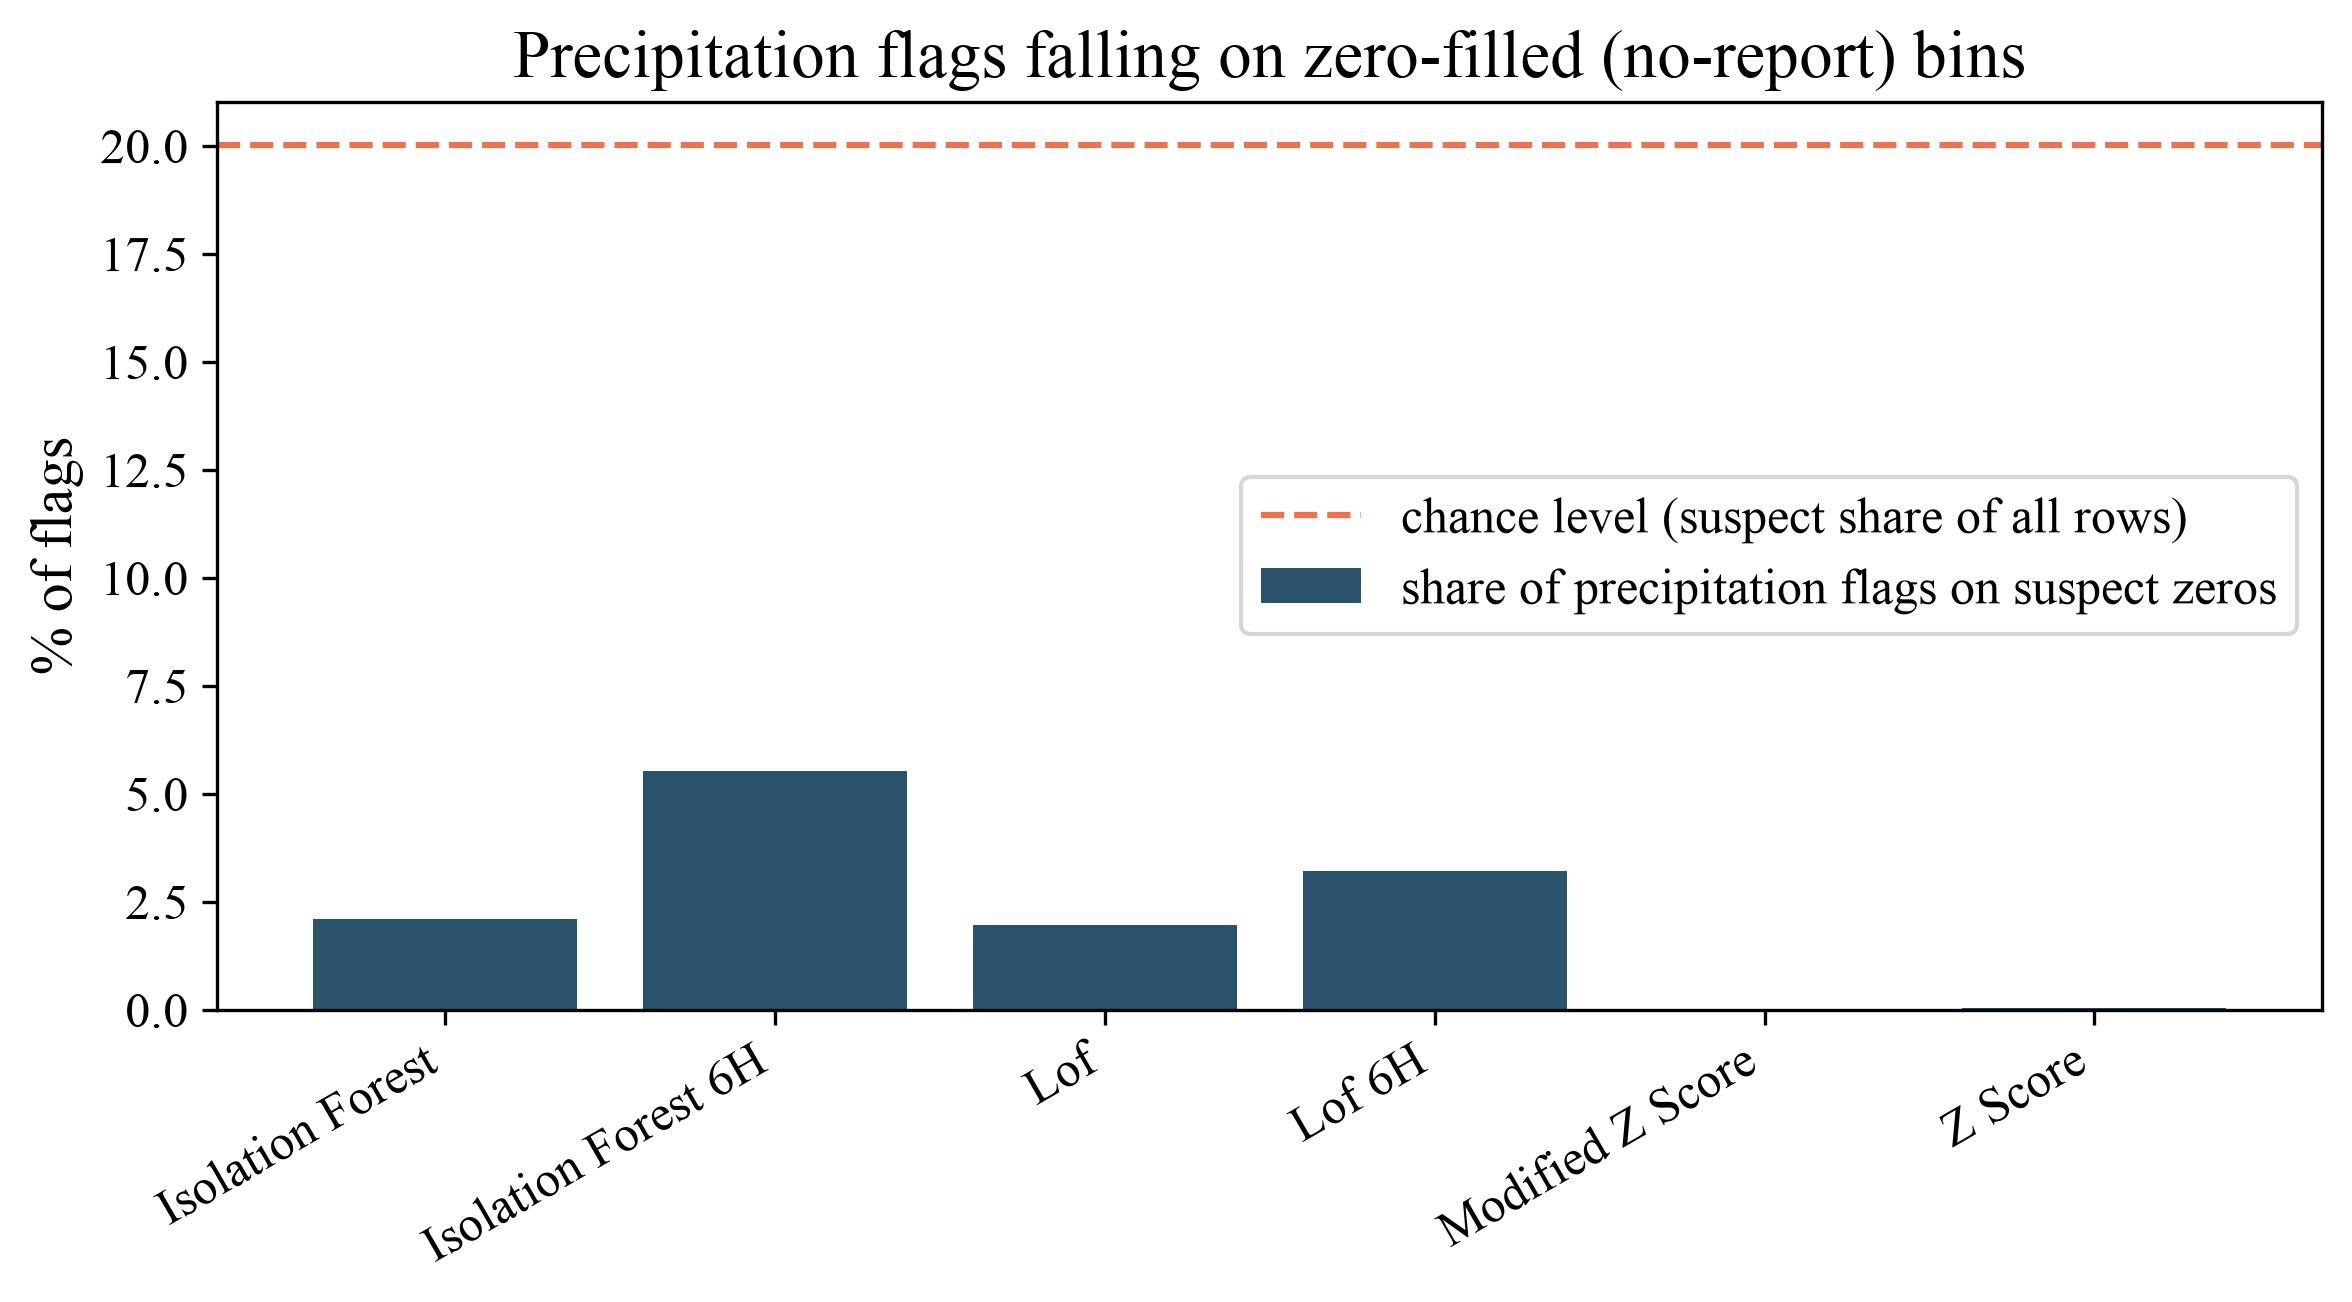

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = overlap.index.tolist()
x = np.arange(len(order))
ax.bar(x, overlap["share_on_suspect_zero"] * 100, color=PALETTE[PALETTE_ORDER[0]],
       label="share of precipitation flags on suspect zeros")
ax.axhline(overlap["baseline_suspect_share"].iloc[0] * 100, color=PALETTE["burnt_sienna"],
           linestyle="--", linewidth=1.5, label="chance level (suspect share of all rows)")
ax.set_xticks(x)
ax.set_xticklabels([pretty_label(m) for m in order], rotation=30, ha="right")
ax.set_ylabel("% of flags")
ax.set_title("Precipitation flags falling on zero-filled (no-report) bins")
ax.legend()
fig.tight_layout()
fig.savefig(DETECT_DIR / "step4b_precip_flag_provenance.png")
plt.show()

## Closing note

These are controls on the Step 4 result, not new detection methods. The
`lof_6h` / `isolation_forest_6h` entries exist to attribute disagreement
between the statistical and density corners to either method family or
window length, and must not be carried into Step 7's method roster as if
they were a seventh and eighth detector.

Whatever these controls show constrains how Steps 5-6 should be
configured: if window length turns out to be a first-order driver of what
a method flags, then the autoencoder's window and the LSTM/GRU sequence
length are not free parameters to be chosen independently — they have to
be set deliberately relative to the other corners, or the plan's stated
goal for Step 6 (isolating the effect of *recurrence* by comparing against
Step 5) is confounded before it starts.